In [1]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt
import spatialmath.base as sb
from spatialmath import SE3

# set matplotlib to interactive mode for inline plotting
plt.ion()
# %matplotlib widget


In [2]:
robot = rtb.models.DH.UR5()
robot.tool = SE3.Tz(0.01)  # Tool frame offset
print(robot)

DHRobot: UR5 (by Universal Robotics), 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │ 0.08946 │       0 │  90.0° │
│  q2 │       0 │  -0.425 │   0.0° │
│  q3 │       0 │ -0.3922 │   0.0° │
│  q4 │  0.1091 │       0 │  90.0° │
│  q5 │ 0.09465 │       0 │ -90.0° │
│  q6 │  0.0823 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──────┬──────────────────────────────────────┐
│ tool │ t = 0, 0, 0.01; rpy/xyz = 0°, 0°, 0° │
└──────┴──────────────────────────────────────┘

┌──────┬───────┬─────┬─────┬─────┬──────┬─────┐
│ name │ q0    │ q1  │ q2  │ q3  │ q4   │ q5  │
├──────┼───────┼─────┼─────┼─────┼──────┼─────┤
│   qr │  180° │  0° │  0° │  0° │  90° │  0° │
│   qz │  0°   │  0° │  0° │  0° │  0°  │  0° │
└──────┴───────┴─────┴─────┴─────┴──────┴─────┘



In [3]:
# 1. Mass of the links
robot.links[0].m = 3.7
robot.links[1].m = 8.393
robot.links[2].m = 2.275
robot.links[3].m = 1.219
robot.links[4].m = 1.219
robot.links[5].m = 0.1879

# 2. Center of mass of each link
robot.links[0].r = [0.0, 0.0, 0.0]
robot.links[1].r = [-0.2125, 0.0, 0.136]
robot.links[2].r = [-0.196125, 0.0, 0.0165]
robot.links[3].r = [0.0, 0.0, 0.0]
robot.links[4].r = [0.0, 0.0, 0.0]
robot.links[5].r = [0.0, 0.0, -0.01525]

# 3. Inertia tensor of each link [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]
robot.links[0].I = [0.014972352344389999, 0.014972352344389999, 0.01040625, 0.0, 0.0, 0.0]
robot.links[1].I = [0.1338857818623325, 0.1338857818623325, 0.0151074, 0.0, 0.0, 0.0]
robot.links[2].I = [0.03121679102890359, 0.03121679102890359, 0.004095, 0.0, 0.0, 0.0]
robot.links[3].I = [0.0020138887777775, 0.0020138887777775, 0.0021942, 0.0, 0.0, 0.0]
robot.links[4].I = [0.0018310388509175, 0.0018310388509175, 0.0021942, 0.0, 0.0, 0.0]
robot.links[5].I = [8.062472608343e-05, 8.062472608343e-05, 0.0001321171875, 0.0, 0.0, 0.0]

# 4. Moment of inertia of the drive
for i in range(6): robot.links[i].Jm = 0.0

# 5. Coefficient of viscous friction
for i in range(6): robot.links[i].B = 0.0

# 6. Coefficient of Coulomb friction
for i in range(6): robot.links[i].Tc = [0.0, 0.0]

# 7. Gear ratio
for i in range(6): robot.links[i].G = 1

# 8. Restrictions on the generalized coordinates
robot.links[0].qlim = [-2*pi, 2*pi]
robot.links[1].qlim = [-2*pi, 2*pi]
robot.links[2].qlim = [-pi, pi]
robot.links[3].qlim = [-2*pi, 2*pi]
robot.links[4].qlim = [-2*pi, 2*pi]
robot.links[5].qlim = [-2*pi, 2*pi]

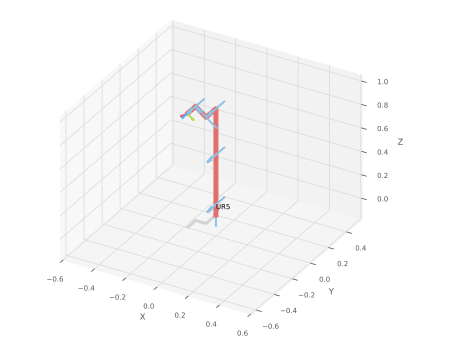

In [4]:
q_start = np.array([0, -pi/2, 0, -pi/4, 0, 0])
# q_start = robot.qr
robot.plot(q_start)
plt.show()

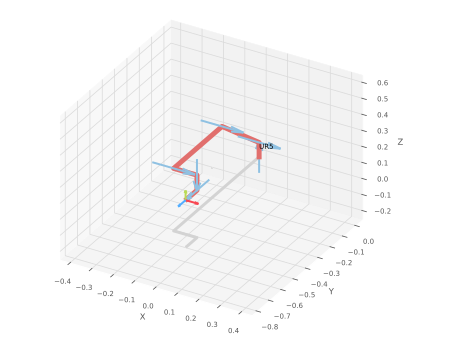

In [5]:
q_end = np.array([pi/2, -pi/4, pi/4, 0, pi/2, 0])
robot.plot(q_end)
plt.show()

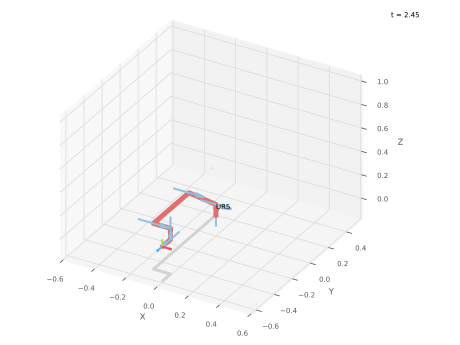

PyPlot3D backend, t = 2.499999999999999, scene:
  robot: Text(0.0, 0.0, 'UR5')

In [6]:
qt = rtb.jtraj(q_start, q_end, 50)
robot.plot(qt.q, backend='pyplot')

In [7]:
type(qt)

roboticstoolbox.tools.trajectory.Trajectory

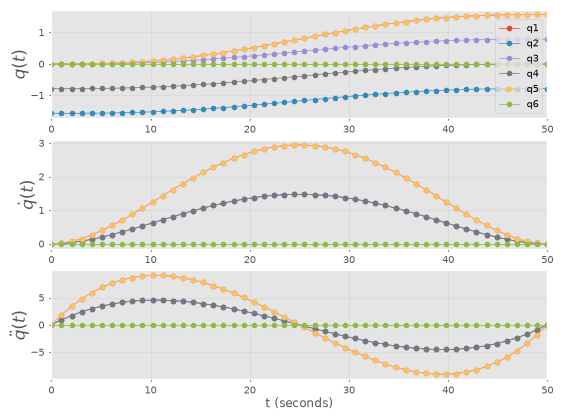

In [8]:
qt.plot()

In [9]:
%store -r contours_mm

In [10]:
def generate_robot_trajectory(contours: list[np.ndarray], H_base_plane: SE3, z_up: float, z_down: float):
    """
    Tạo quỹ đạo di chuyển cho end-effector của robot.
    
    Args:
        contours: Danh sách các nét vẽ (mm).
        H_base_plane: Đối tượng SE3/Ma trận 4x4 chuyển đổi từ hệ tọa độ base robot sang mặt phẳng vẽ.
        z_up: Độ cao khi nhấc bút (so với mặt phẳng vẽ, mm).
        z_down: Độ cao khi hạ bút để vẽ (so với mặt phẳng vẽ, mm).
        
    Returns:
        trajectory: Mảng numpy shape (N, 3) hoặc (N, 6) chứa chuỗi các điểm di chuyển.
    """
    trajectory = []
    
    # Bước nhảy giữa các điểm
    for cnt in contours:
        pts = cnt.reshape(-1, 2)
        if len(pts) == 0:
            continue
            
        # 1. Di chuyển tới điểm bắt đầu ở độ cao z_up
        start_pt = pts[0]
        trajectory.append(H_base_plane * SE3(start_pt[0], start_pt[1], z_up) * SE3.OA([0, 1, 0], [0, 0, -1]))
        
        # 2. Hạ bút xuống z_down
        trajectory.append(H_base_plane * SE3(start_pt[0], start_pt[1], z_down) * SE3.OA([0, 1, 0], [0, 0, -1]))
        
        # 3. Vẽ toàn bộ các điểm trong contour ở độ cao z_down
        for pt in pts[1:]:
            trajectory.append(H_base_plane * SE3(pt[0], pt[1], z_down) * SE3.OA([0, 1, 0], [0, 0, -1]))
            
        # 4. Nhấc bút lên lại z_up sau khi kết thúc nét vẽ
        end_pt = pts[-1]
        trajectory.append(H_base_plane * SE3(end_pt[0], end_pt[1], z_up) * SE3.OA([0, 1, 0], [0, 0, -1]))
        
    return trajectory


H_base_plane = SE3(-0.8, 0.0, 0.1)

Z_UP = 0.05   # m cao hơn mặt phẳng
Z_DOWN = 0.0  # Chạm mặt phẳng

# Tạo quỹ đạo từ bộ contour đã resample (dùng contours_mm hoặc contours_scipy)
contours_m = [contour / 1000.0 for contour in contours_mm]  # Chuyển đổi từ mm sang m nếu cần
robot_traj_m = generate_robot_trajectory(contours_m, H_base_plane, Z_UP, Z_DOWN)

print(f"Tổng số điểm trong quỹ đạo robot: {len(robot_traj_m)}")
print(f"Ví dụ 5 điểm đầu tiên:\n{robot_traj_m[:5]}")


Tổng số điểm trong quỹ đạo robot: 1025
Ví dụ 5 điểm đầu tiên:
[SE3(array([[-1.        ,  0.        ,  0.        , -0.74719022],
           [ 0.        ,  1.        ,  0.        ,  0.26391035],
           [ 0.        ,  0.        , -1.        ,  0.15      ],
           [ 0.        ,  0.        ,  0.        ,  1.        ]])), SE3(array([[-1.        ,  0.        ,  0.        , -0.74719022],
           [ 0.        ,  1.        ,  0.        ,  0.26391035],
           [ 0.        ,  0.        , -1.        ,  0.1       ],
           [ 0.        ,  0.        ,  0.        ,  1.        ]])), SE3(array([[-1.        ,  0.        ,  0.        , -0.74772826],
           [ 0.        ,  1.        ,  0.        ,  0.2644484 ],
           [ 0.        ,  0.        , -1.        ,  0.1       ],
           [ 0.        ,  0.        ,  0.        ,  1.        ]])), SE3(array([[-1.        ,  0.        ,  0.        , -0.74692119],
           [ 0.        ,  1.        ,  0.        ,  0.26391035],
           [ 0.   

In [11]:
# compute the joint angles for each point in the trajectory
joint_configs = []
failures = 0
sol = None
for pose in robot_traj_m:
    # Use inverse kinematics to compute joint angles for the given pose
    sol = robot.ikine_LM(SE3(pose), q0=q_start if sol is None else sol.q)  # Using Levenberg-Marquardt method
    if sol.success:
        joint_configs.append(sol.q)
    else:
        print(f"IK failed.")
        # joint_configs.append(None)  # Append None or handle as needed
        failures += 1

joint_configs = np.array(joint_configs)

print(f"Total IK failures: {failures} out of {len(robot_traj_m)} points.")


Total IK failures: 0 out of 1025 points.


In [12]:
joint_configs

array([[-0.47770661, -0.72071234,  1.05211168, -1.90219566, -1.57079633,
        -2.04850293],
       [-0.4777066 , -0.67132777,  1.09573264, -1.99520121, -1.57079634,
        -2.04850293],
       [-0.47800022, -0.66965651,  1.09250551, -1.99364533, -1.57079634,
        -2.04879655],
       ...,
       [-0.22558916, -0.74357856,  1.23430005, -2.06151782, -1.57079633,
        -1.79638549],
       [-0.21426374, -0.72115272,  1.19149866, -2.04114227, -1.57079633,
        -1.78506007],
       [-0.2142637 , -0.77362788,  1.14986393, -1.94703241, -1.57079633,
        -1.78506003]], shape=(1025, 6))

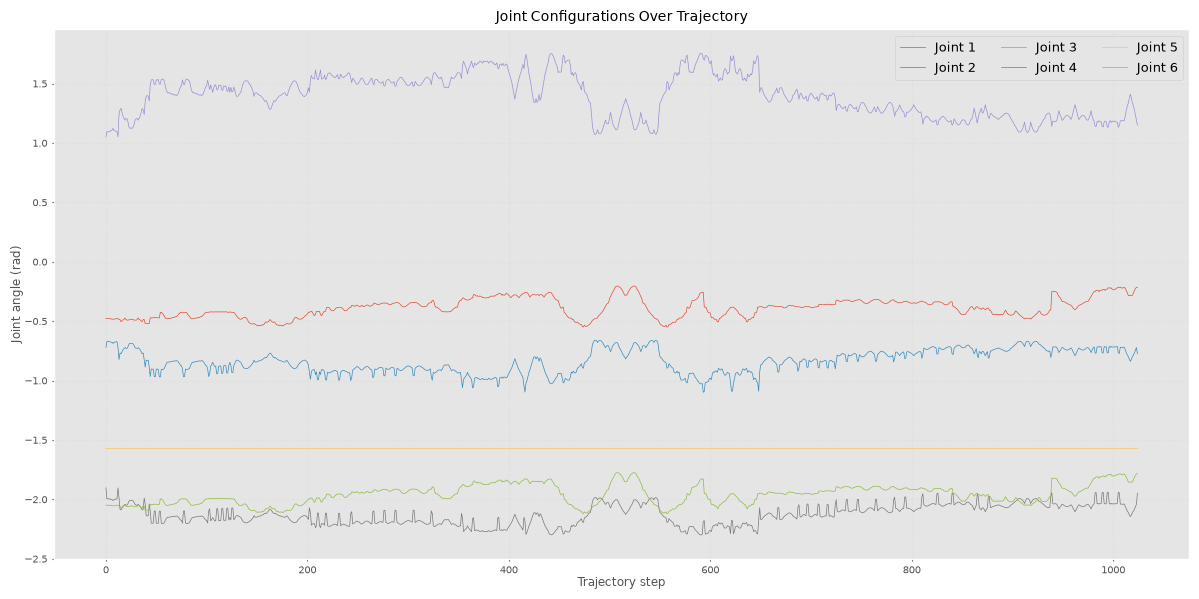

In [13]:
# Plot joint configurations with matplotlib

fig, ax = plt.subplots(figsize=(12, 6))
time = np.arange(len(joint_configs))

for joint_idx in range(joint_configs.shape[1]):
    ax.plot(time, joint_configs[:, joint_idx], label=f"Joint {joint_idx + 1}")

ax.set_title("Joint Configurations Over Trajectory")
ax.set_xlabel("Trajectory step")
ax.set_ylabel("Joint angle (rad)")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()


In [14]:
# robot.plot(joint_configs, backend='pyplot')

In [15]:
import mujoco
import mujoco.viewer
import numpy as np
import time
import mediapy as media

# Load the UR5e model
model = mujoco.MjModel.from_xml_path(
    "../mujoco_menagerie/universal_robots_ur5e/scene.xml"
)
data = mujoco.MjData(model)

cam = mujoco.MjvCamera()
cam.lookat[:] = [0.0, 0.0, 0.5]
cam.distance = 1.5
cam.azimuth = 90
cam.elevation = -20

print("=== UR5e Model Info ===")
print(f"Number of joints (DoF): {model.nv}")
print(f"Number of actuators:    {model.nu}")
print(f"Joint names:")
for i in range(model.njnt):
    print(f"  Joint {i}: {mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, i)}")

=== UR5e Model Info ===
Number of joints (DoF): 6
Number of actuators:    6
Joint names:
  Joint 0: shoulder_pan_joint
  Joint 1: shoulder_lift_joint
  Joint 2: elbow_joint
  Joint 3: wrist_1_joint
  Joint 4: wrist_2_joint
  Joint 5: wrist_3_joint


In [16]:


framerate = 60  # (Hz)
duration = len(joint_configs) / framerate  # (seconds)

q_history = []
qd_history = []
qdd_history = []

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:

    # assign the joint positions from the trajectory to the simulation data
    q = joint_configs[int(data.time * framerate)]
    # qd = trajectory.qd[int(data.time * framerate)]
    # qdd = trajectory.qdd[int(data.time * framerate)]

    # data.qpos[:6] = q
    # data.qvel[:6] = qd
    # data.qacc[:6] = qdd

    data.ctrl[:6] = q  # Set the control inputs to the joint positions

    q_history.append(data.qpos[:6].copy())  # Store the joint positions for later analysis
    qd_history.append(data.qvel[:6].copy())  # Store the joint velocities for later analysis
    qdd_history.append(data.qacc[:6].copy())  # Store the joint accelerations for later analysis

    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data, camera=cam)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


In [17]:
%store joint_configs
%store robot_traj_m

Stored 'joint_configs' (ndarray)
Stored 'robot_traj_m' (list)


In [18]:
# convert robot_traj_m to [x, y, z, rx, ry, rz]
path = []
for pose in robot_traj_m:
    # Convert SE3 to [x, y, z, rx, ry, rz]
    x, y, z = pose.t
    rpy = pose.rpy()  # Returns [roll, pitch, yaw]
    path.append([x, y, z] + list(rpy))
path = np.array(path)

In [19]:
%store path

Stored 'path' (ndarray)
